In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import seaborn as sns
import matplotlib.pyplot as plt
from lazypredict import LazyRegressor

In [2]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)


In [3]:
# load raw data

#df_raw = pd.read_csv('food_prediction_raw.csv')
df_raw = pd.read_csv('df_cleaned.csv', index_col=0)
df_raw.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,week,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0


In [ ]:
df_raw.info

In [36]:
### check check

df_raw.groupby('zipcode')['store_id'].apply(lambda x:str(len(set(x))) + ' stores -> ' +  str(set(x))).sort_values(ascending=False)

zipcode
52146    5 stores -> {33, 18, 52, 24, 28}
52064           4 stores -> {9, 12, 5, 7}
52249        4 stores -> {54, 20, 29, 38}
52477        4 stores -> {26, 55, 47, 23}
52066         4 stores -> {10, 11, 6, 22}
52062          4 stores -> {0, 51, 58, 3}
52134              3 stores -> {8, 2, 39}
52222             3 stores -> {56, 57, 4}
52428            3 stores -> {32, 44, 31}
52074            3 stores -> {17, 59, 13}
52156                2 stores -> {48, 49}
52499                2 stores -> {43, 30}
52070                2 stores -> {42, 21}
52531                2 stores -> {40, 45}
52080                2 stores -> {34, 36}
52078                2 stores -> {25, 19}
52072                2 stores -> {16, 15}
52351                    1 stores -> {53}
52382                    1 stores -> {50}
52159                    1 stores -> {46}
52068                    1 stores -> {41}
52076                    1 stores -> {37}
52152                    1 stores -> {35}
52223                    1

## Creating Lag Features

__Issue__: No continuous time range__
+ If an item is not sold on a certain date/store there is ==no record== and thus no date. That breaks the date range

__Solution:__ we first have to create a consecutive date range, to get correct lag features afterwards.
+ Lags:
    * t-1 
    * t-3
    * t-7
    * ~~t-14~~

In [5]:
# sort new copy in preperation for correct lag features
df = df_raw.sort_values(['store_id', 'item_id', 'date']).copy()

# convert date
df['date'] = pd.to_datetime(df.date)

# deleting cols month, day_of_week, week for now  --> because after reindexing we have new rows of these cols with NaN --> we add them later again after reindexing
df = df.drop(columns=['month', 'day_of_week', 'week'])

df.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
37918,2025-04-05,Kuchen,1,0.0,12.00,0.00,0,52062,11.916667,14.333333,51.833333,NE,Sunny,0.000000,59.875000,10.000000,1017.666667,13.583333,3.833333,21.916667,2.625000,520622025-04-05,0,0,0
99085,2025-04-12,Kuchen,1,0.0,12.00,0.00,0,52062,14.208333,13.833333,139.875000,SE,Sunny,0.004167,60.583333,10.000000,1012.000000,12.041667,6.291667,21.583333,2.916667,520622025-04-12,0,1,0
252700,2025-05-03,Kuchen,1,0.0,12.00,0.00,0,52062,13.416667,8.583333,264.500000,WNW,Light rain shower,0.270833,91.333333,8.291667,1011.583333,68.583333,12.041667,12.833333,2.250000,520622025-05-03,0,0,0
374345,2025-05-17,Kuchen,1,1.0,11.25,11.25,0,52062,11.541667,8.500000,304.375000,N,Sunny,0.000000,71.291667,8.000000,1019.375000,24.750000,5.916667,12.750000,2.666667,520622025-05-17,0,0,0
435176,2025-05-24,Kuchen,1,1.0,11.25,11.25,0,52062,10.125000,19.666667,214.250000,SSW,Partly cloudy,0.166667,74.833333,8.916667,1016.458333,78.125000,5.541667,30.750000,2.000000,520622025-05-24,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 731228 entries, 37918 to 731128
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 731228 non-null  datetime64[us]
 1   category_name        731228 non-null  str           
 2   item_id              731228 non-null  int64         
 3   sold_quantity        731228 non-null  float64       
 4   price                731228 non-null  float64       
 5   revenue              731228 non-null  float64       
 6   store_id             731228 non-null  int64         
 7   zipcode              731228 non-null  int64         
 8   temperature          731228 non-null  float64       
 9   wind_speed           731228 non-null  float64       
 10  wind_degree          731228 non-null  float64       
 11  wind_dir             731228 non-null  str           
 12  weather_description  731228 non-null  str           
 13  precip               73122

In [7]:
df = df.set_index(['store_id', 'item_id', 'date'])
df.head(15)

category_name  sold_quantity  price  revenue  \
store_id item_id date                                                      
0        1       2025-04-05        Kuchen            0.0  12.00     0.00   
                 2025-04-12        Kuchen            0.0  12.00     0.00   
                 2025-05-03        Kuchen            0.0  12.00     0.00   
                 2025-05-17        Kuchen            1.0  11.25    11.25   
                 2025-05-24        Kuchen            1.0  11.25    11.25   
                 2025-06-07        Kuchen            0.0  12.00     0.00   
                 2025-06-28        Kuchen            0.0  12.00     0.00   
         7       2025-04-01      Brötchen            9.0   0.70     6.30   
                 2025-04-02      Brötchen            3.0   0.70     2.10   
                 2025-04-03      Brötchen           13.0   0.70     9.10   
                 2025-04-04      Brötchen            2.0   0.70     1.40   
                 2025-04-05      Brötchen           18.0   0.70    12.60   
                 2025-04-07      Brötchen            7.0   0.70     4.90   
                 2025-04-08      Brötchen            2.0   0.70     1.40   
                 2025-04-11      Brötchen           12.0   0.70     8.40   

                             zipcode  temperature  wind_speed  wind_degree  \
store_id item_id date                                                        
0        1       2025-04-05    52062    11.916667   14.333333    51.833333   
                 2025-04-12    52062    14.208333   13.833333   139.875000   
                 2025-05-03    52062    13.416667    8.583333   264.500000   
                 2025-05-17    52062    11.541667    8.500000   304.375000   
                 2025-05-24    52062    10.125000   19.666667   214.250000   
                 2025-06-07    52062    13.500000   20.291667   225.166667   
                 2025-06-28    52062    22.541667   16.125000   259.125000   
         7       2025-04-01    52062     7.541667   16.500000    78.625000   
                 2025-04-02    52062     9.791667   22.083333    82.333333   
                 2025-04-03    52062    12.208333   17.291667   104.500000   
                 2025-04-04    52062    12.833333   11.291667    85.458333   
                 2025-04-05    52062    11.916667   14.333333    51.833333   
                 2025-04-07    52062     6.458333   10.166667    74.125000   
                 2025-04-08    52062     8.458333    8.750000    71.083333   
                 2025-04-11    52062    10.375000    6.500000   221.833333   

                            wind_dir   weather_description    precip  \
store_id item_id date                                                  
0        1       2025-04-05       NE                 Sunny  0.000000   
                 2025-04-12       SE                 Sunny  0.004167   
                 2025-05-03      WNW     Light rain shower  0.270833   
                 2025-05-17        N                 Sunny  0.000000   
                 2025-05-24      SSW         Partly cloudy  0.166667   
                 2025-06-07       SW  Patchy rain possible  0.208333   
                 2025-06-28        W                 Clear  0.000000   
         7       2025-04-01        E                 Clear  0.000000   
                 2025-04-02        E                 Clear  0.000000   
                 2025-04-03      ESE                 Sunny  0.000000   
                 2025-04-04      ESE                 Clear  0.000000   
                 2025-04-05       NE                 Sunny  0.000000   
                 2025-04-07      ESE                 Clear  0.000000   
                 2025-04-08      ESE                 Sunny  0.000000   
                 2025-04-11       NW                 Clear  0.000000   

                              humidity  visibility     pressure  cloudcover  \
store_id item_id date                                                         
0        1       2025-04-

In [8]:
df.sold_quantity.isna().sum()

np.int64(0)

In [9]:
# creating full date range for lags

all_dates = pd.date_range(df.index.get_level_values('date').min(), df.index.get_level_values('date').max(), freq='D')
all_stores = df.index.get_level_values('store_id').unique()
all_items = df.index.get_level_values('item_id').unique()

new_index = pd.MultiIndex.from_product([all_stores, all_items, all_dates],  names=['store_id', 'item_id', 'date'])

df = df.reindex(new_index)

# not neccessary, delete!
# filling NaN in target with 0 for training target must not be NaN
# df['sold_quantity'] = df['sold_quantity'].fillna(0)


In [10]:
# check
df.head(10)
#df.query('item_id == 7').head(20).info()

df.sold_quantity.isna().sum()

np.int64(3718672)

In [11]:
# creating lags

lags = [1, 3, 7]

for lag in lags:
    df[f'lag_{lag}'] = df.groupby(['store_id', 'item_id'])['sold_quantity'].shift({lag})
    


In [12]:
# check
#df.iloc[2000000:2000100]
#df.query('lag_1.notna() and item_id == 7').head(20)


## Creating Rolling Feature

__rollings__
* mean_7
* ~~mean_14~~
* median_7
+ difference between mean / median (when high value than more outliers)
+ ~~7-day trend~~
* sum_7
* std_7

In [13]:
# creating rollings

# reset for better handling
df = df.reset_index()

# less writing, -> shift(1) to exclude the current target value of the calculation of the mean/median/sum/std
shifted_group = df.groupby(['store_id', 'item_id'])['sold_quantity'].shift(1)

#...mean and median
df['rolling_mean_7'] = shifted_group.rolling(7).mean()
df['rolling_median_7'] = shifted_group.rolling(7).median()

# rolling mean 14 days back
# df['rolling_mean_14'] = shifted_group.rolling(14).mean()

# ...sum
df['rolling_sum_7'] = shifted_group.rolling(7).sum()

# ...std
df['rolling_std_7'] = shifted_group.rolling(7).std()

# last 7 day trend
# df['trend_7'] = df.rolling_mean_7 - df.rolling_mean_14 / (df['rolling_mean_14'] + 1e-8)

# mean median diff -> low == stable sold_qty, high == outliers
df['mean_median_diff_7'] = df['rolling_mean_7'] - df['rolling_median_7']

# reset multiindex
df = df.set_index(['store_id', 'item_id', 'date'])

In [14]:
# check
# print(df[['lag_1', 'lag_3', 'lag_7']].isna().sum().sum())
# print(len(df))

# gone = df[['lag_1', 'lag_3', 'lag_7']].isna().sum().sum() / len(df)
# print(gone)

df.isna().sum()

category_name          3718672
sold_quantity          3718672
price                  3718672
revenue                3718672
zipcode                3718672
temperature            3718672
wind_speed             3718672
wind_degree            3718672
wind_dir               3718672
weather_description    3718672
precip                 3718672
humidity               3718672
visibility             3718672
pressure               3718672
cloudcover             3718672
dewpoint               3718672
windgust               3718672
uv_index               3718672
date_zipcode           3718672
special_day            3718672
school_holiday         3718672
std_holiday            3718672
lag_1                  3727003
lag_3                  3740324
lag_7                  3777013
rolling_mean_7         4290792
rolling_median_7       4290792
rolling_sum_7          4290792
rolling_std_7          4290792
mean_median_diff_7     4290792
dtype: int64

In [15]:
# removing missing values in lag 1, 3, 7 at the beginning of each date/item time span.

lag_cols = ['lag_1', 'lag_3', 'lag_7']

# proportion of data loss after deleting rows where lags are missing
print('Data loss after removing NaN in lags:\n')
print(df[lag_cols].isna().sum() / df.shape[0])

# removing lags with missing values at the beginning (first 7 days)

df = df.dropna(subset=lag_cols)
print('-'*40)
print('--- removing missing values in lags... ---- ')
print('-'*40)
print('\nMissing values in lags after removing:\n')
print(df[lag_cols].isna().sum() / df.shape[0])



Data loss after removing NaN in lags:

lag_1    0.837548
lag_3    0.840541
lag_7    0.848786
dtype: float64
----------------------------------------
--- removing missing values in lags... ---- 
----------------------------------------

Missing values in lags after removing:

lag_1    0.0
lag_3    0.0
lag_7    0.0
dtype: float64


In [16]:
# remove all missing values
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 141818 entries, (np.int64(0), np.int64(22), Timestamp('2025-04-08 00:00:00')) to (np.int64(59), np.int64(876), Timestamp('2025-06-03 00:00:00'))
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   category_name        141818 non-null  str    
 1   sold_quantity        141818 non-null  float64
 2   price                141818 non-null  float64
 3   revenue              141818 non-null  float64
 4   zipcode              141818 non-null  float64
 5   temperature          141818 non-null  float64
 6   wind_speed           141818 non-null  float64
 7   wind_degree          141818 non-null  float64
 8   wind_dir             141818 non-null  str    
 9   weather_description  141818 non-null  str    
 10  precip               141818 non-null  float64
 11  humidity             141818 non-null  float64
 12  visibility           141818 non-null  float64
 13  pressure     

## (Re-)Creating Temporal Features
from 'date'
* month
* week
* day_of_week


In [17]:
# check
pd.set_option('display.max_columns', None)



In [18]:
# reset multiindex first - otherwise .isocalender().week will not work
df = df.reset_index()

# new time features
df['month'] = df.date.dt.month
df['week'] = df.date.dt.isocalendar()['week']
df['day_of_week'] = df.date.dt.dayofweek

# setting back to mulitindex - not needed form here
#df = df.set_index(['store_id', 'item_id', 'date'])


In [19]:
df.head()

,store_id,item_id,date,category_name,sold_quantity,price,revenue,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week
0,0,22,2025-04-08,Brötchen,13.0,0.86,11.18,52062.0,8.458333,8.750000,71.083333,ESE,Sunny,0.000000,58.375000,10.0,1026.875000,15.333333,0.416667,14.625000,2.291667,520622025-04-08,0.0,0.0,0.0,5.0,5.0,8.0,11.571429,8.0,81.0,12.634043,3.571429,4,15,1
1,0,22,2025-04-09,Brötchen,7.0,0.90,6.30,52062.0,9.208333,9.625000,103.541667,N,Clear,0.000000,65.208333,10.0,1025.625000,25.375000,2.916667,14.625000,2.291667,520622025-04-09,0.0,0.0,0.0,13.0,40.0,9.0,12.285714,8.0,86.0,12.539462,4.285714,4,15,2
2,0,22,2025-04-10,Brötchen,11.0,0.90,9.90,52062.0,8.250000,9.625000,269.291667,NW,Clear,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,520622025-04-10,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3
3,0,22,2025-04-11,Brötchen,14.0,0.90,12.60,52062.0,10.375000,6.500000,221.833333,NW,Clear,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,520622025-04-11,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4
4,0,22,2025-04-12,Brötchen,5.0,0.81,4.05,52062.0,14.208333,13.833333,139.875000,SE,Sunny,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,520622025-04-12,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5


In [20]:
# check

# # needed for training: change non-numerical dtypes to ´category´
# cat_list = ['category_name', 'wind_dir', 'weather_description', 'date_zipcode']

# for col in cat_list:
#     df[col] = df[col].astype('category')


## __Create Train/Test Set__ - train test split

In [21]:
# counting all days in the dataset
#all_days = df['date'].nunique()#

## 80 % for train set
#days_for_train = int(all_days * 0.8)
#days_for_test = all_days - days_for_train #int(all_days * 0.2)#

## get date for split
#start_date = df['date'].min()
#end_date = df['date'].max()#

#split_date = start_date + pd.Timedelta(days=days_for_train)#
#

## manual split#

## 80 % train
#train = df[df['date'] < split_date]#

## 20 % test
#test  = df[df['date'] >= split_date]

train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=False)

print('Train:', train.shape, train['date'].min(), train['date'].max())
print('Test:', test.shape, test['date'].min(), test['date'].max())

## reconsider

Train: (113454, 36) 2025-04-08 00:00:00 2025-06-30 00:00:00
Test: (28364, 36) 2025-04-08 00:00:00 2025-06-30 00:00:00


## __Encoding__
### Target Encoding (NUR item_id)


In [22]:
# check

df_raw.category_name.nunique()

21

In [23]:
# encoding 1

# target encoding .....for item per store, zipcode, store_id

#-------------

# fallback für test set
global_mean = train['sold_quantity'].mean()  # only for item_id per store


# traget encoding item_id (per store)
train['item_id_tar_enc'] = train.groupby(['store_id', 'item_id'])['sold_quantity'].shift(1).expanding().mean()

# last exp means item_id per store
last_item_id_mean = train.groupby(['store_id','item_id'])['item_id_tar_enc'].last()

# map last_mean to test set
test['item_id_tar_enc'] = test.apply(lambda row: last_item_id_mean.get((row['store_id'], row['item_id']), global_mean), axis=1)

#-------------

# # target encoding per store_id
# train['store_id_tar_enc'] = train.groupby(['store_id'])['sold_quantity'].shift(1).expanding().mean()# 

# # last exp mean store_id
# last_store_id_mean = train.groupby(['store_id'])['store_id_tar_enc'].last()# 

# # map last_mean to test set
# test['store_id_tar_enc'] = test.apply(lambda row: last_store_id_mean.get((row['store_id']), np.nan),axis=1)# 

# #-------------# 

# # target encoding zipcode
# train['zipcode_tar_enc'] = train.groupby(['zipcode'])['sold_quantity'].shift(1).expanding().mean()# 

# # last exp mean zipcode
# last_zipcode_mean = train.groupby(['zipcode'])['zipcode_tar_enc'].last()# 

# # map last_mean to test set
# test['zipcode_tar_enc'] = test.apply(lambda row: last_zipcode_mean.get((row['zipcode']), np.nan),axis=1)# 

# #-------------# 

# # target encoding weather_description
# train['weather_descr_tar_enc'] = train.groupby(['weather_description'])['sold_quantity'].shift(1).expanding().mean()# 

# # last exp mean weather_description
# last_weather_desc_mean = train.groupby(['weather_description'])['weather_descr_tar_enc'].last()# 

# # map last_mean to test set
# test['weather_descr_tar_enc'] = test.apply(lambda row: last_weather_desc_mean.get((row['weather_description']), np.nan),axis=1)# 

# # add store...



In [24]:
# check 
test['item_id_tar_enc'].nunique()
test['item_id_tar_enc'].isna().sum()


np.int64(0)

### - NO OHE  - One Hot Encoding

In [25]:
# encoding 2
## One Hot Encoding
# from sklearn.preprocessing import OneHotEncoder# 

# # instatiate encoder
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')# 

# # encode category_name  -  and apply to train and test set
# train_cat_encoded = ohe.fit_transform(train[['category_name']])
# test_cat_encoded = ohe.transform(test[['category_name']])# 

# # make it a dataframe
# df_train_cat_encoded = pd.DataFrame(train_cat_encoded, columns=(ohe.get_feature_names_out(['category_name'])), index=train.index)
# df_test_cat_encoded = pd.DataFrame(test_cat_encoded, columns=(ohe.get_feature_names_out(['category_name'])), index=test.index)# 

# # join with origin df
# train = train.drop(columns=['category_name']).join(df_train_cat_encoded)
# test = test.drop(columns=['category_name']).join(df_test_cat_encoded)# 
# 
# 
# 

# train.head()# 




### __clean up__

In [26]:
# delete 3x wind + datezipcode....(?)
train = train.drop(columns=['wind_dir', 'wind_gust', 'wind_degree', 'wind_speed', 'date_zipcode'], errors='ignore')
test = test.drop(columns=['wind_dir', 'wind_gust', 'wind_degree', 'wind_speed', 'date_zipcode'], errors='ignore')
train.head()

,store_id,item_id,date,category_name,sold_quantity,price,revenue,zipcode,temperature,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week,item_id_tar_enc
0,0,22,2025-04-08,Brötchen,13.0,0.86,11.18,52062.0,8.458333,Sunny,0.000000,58.375000,10.0,1026.875000,15.333333,0.416667,14.625000,2.291667,0.0,0.0,0.0,5.0,5.0,8.0,11.571429,8.0,81.0,12.634043,3.571429,4,15,1,NaN
1,0,22,2025-04-09,Brötchen,7.0,0.90,6.30,52062.0,9.208333,Clear,0.000000,65.208333,10.0,1025.625000,25.375000,2.916667,14.625000,2.291667,0.0,0.0,0.0,13.0,40.0,9.0,12.285714,8.0,86.0,12.539462,4.285714,4,15,2,13.000000
2,0,22,2025-04-10,Brötchen,11.0,0.90,9.90,52062.0,8.250000,Clear,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3,10.000000
3,0,22,2025-04-11,Brötchen,14.0,0.90,12.60,52062.0,10.375000,Clear,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4,10.333333
4,0,22,2025-04-12,Brötchen,5.0,0.81,4.05,52062.0,14.208333,Sunny,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5,11.250000


In [27]:
# keeping date seperate for plotting later
train_dates = train['date']
test_dates = test['date']

# remove store_id, item_id, date --> all are encoded now (item -> target encode, date -> temporal features)
train = train.drop(columns=['item_id'])
test = test.drop(columns=['item_id'])

In [28]:
# new missing values?
missing_train = train.isna().sum()
print('Missing Train set:')
print(missing_train[missing_train > 0])
print()
missing_test = test.isna().sum()
print('Missing Test set:')
print(missing_test[missing_test > 0])

# # delete new missing values iun train set after encoding
train = train.dropna()


missing_train = train.isna().sum()
print('Missing Train set after removing:')
print(missing_train[missing_train > 0])
print()


Missing Train set:
item_id_tar_enc    1
dtype: int64

Missing Test set:
Series([], dtype: int64)
Missing Train set after removing:
Series([], dtype: int64)



In [29]:
print('traindates', len(train_dates))
print('train', len(train))

traindates 113454
train 113453


### __Defining categorical columns for lightGBM param__

In [30]:
# we will need this list later in LightGBM
categorical_cols = ['store_id', 'category_name', 'zipcode', 'weather_description']

# change dtype for lightgbm
for col in categorical_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

train.info()    

<class 'pandas.DataFrame'>
RangeIndex: 113453 entries, 1 to 113453
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   store_id             113453 non-null  category      
 1   date                 113453 non-null  datetime64[us]
 2   category_name        113453 non-null  category      
 3   sold_quantity        113453 non-null  float64       
 4   price                113453 non-null  float64       
 5   revenue              113453 non-null  float64       
 6   zipcode              113453 non-null  category      
 7   temperature          113453 non-null  float64       
 8   weather_description  113453 non-null  category      
 9   precip               113453 non-null  float64       
 10  humidity             113453 non-null  float64       
 11  visibility           113453 non-null  float64       
 12  pressure             113453 non-null  float64       
 13  cloudcover           1134

## __Split explanatory data (X) and target (y)__

In [31]:
# create exploratory and target variables

# train
X_train = train.drop(columns=['sold_quantity', 'date'])
y_train = train['sold_quantity']

# test
X_test = test.drop(columns=['sold_quantity', 'date'])
y_test = test['sold_quantity']


In [37]:
train_dates

0        2025-04-08
1        2025-04-09
2        2025-04-10
3        2025-04-11
4        2025-04-12
            ...    
113449   2025-05-09
113450   2025-05-10
113451   2025-05-11
113452   2025-05-12
113453   2025-05-13
Name: date, Length: 113454, dtype: datetime64[us]

## __No Scaling__

In [139]:
# scaling X

# from sklearn.preprocessing import RobustScaler# 

# scaler = RobustScaler()# 

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)# 

# X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)# 




In [140]:
# check
# print(X_train_scaled.shape, y_train.shape)
# print(X_test_scaled.shape, y_test.shape)

In [141]:
# check

# X_train_scaled.head(20)

In [142]:
# X_train["category_name_Angebot Brot"].unique()

## __Model Selection__

In [38]:
import xgboost
import lightgbm
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, BaggingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

In [144]:
from lazypredict import LazyRegressor
import tqdm

### Naive Baseline (lags)

In [39]:
# naive baseline models for benchmark

baseline_cols = ['lag_1', 'lag_3', 'lag_7']

def baseline_metric(X_test, y_test, baseline_cols):
    '''creating MAE and RMSE for baseline model'''
    for col in baseline_cols:
        without_NaN = X_test[col].notna()
        y_true = y_test[without_NaN]
        y_pred = X_test.loc[without_NaN, col]

        print(f'{col} Baseline:')
        print('MAE:', mean_absolute_error(y_true, y_pred))
        print('RMSE:', np.sqrt(mean_squared_error(y_true, y_pred)))
        print('-'*30)

print('Baselines\nX_test, y_test:\n')
baseline_metric(X_test, y_test, baseline_cols)


Baselines
X_test, y_test:

lag_1 Baseline:
MAE: 15.690102242278947
RMSE: 71.03578241241384
------------------------------
lag_3 Baseline:
MAE: 18.937605380059228
RMSE: 75.42264593419135
------------------------------
lag_7 Baseline:
MAE: 9.715883761105626
RMSE: 47.607500035456276
------------------------------


In [40]:
# reset indices , to be in sync again

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

### LazyRegressor

In [147]:
# check
# print(X_train_scaled.shape, y_train.shape)
# print(X_test_scaled.shape, y_test.shape)

In [148]:
# reduce data amount for Lazypredict
shrink_factor = 0.15

# reducing training data
X_train_idx = int(np.floor(X_train.shape[0] * shrink_factor))
y_train_idx = int(np.floor(y_train.shape[0] * shrink_factor))

print(X_train_idx, y_train_idx)

X_train_lazy = X_train[: X_train_idx]
y_train_lazy = y_train[: y_train_idx]



# reducing test data
X_test_idx = int(np.floor(X_test.shape[0] * shrink_factor))
y_test_idx = int(np.floor(y_test.shape[0] * shrink_factor))

print(X_test_idx, y_test_idx)

X_test_lazy = X_test[: X_test_idx]
y_test_lazy = y_test[: y_test_idx]



17017 17017
4254 4254


In [149]:
# check
print(X_train_lazy.shape, y_train_lazy.shape)
print(X_test_lazy.shape, y_test_lazy.shape)

(17017, 30) (17017,)
(4254, 30) (4254,)


In [150]:
#lazy_reg = LazyRegressor(verbose=1, ignore_warnings=True, predictions=True, random_state=42)

#models, predictions = lazy_reg.fit(X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy)



In [151]:
#print(models)

### __Models 1st try__

In [41]:
# classifier to compare

models = {
    #'Xgboost': xgboost.XGBRegressor(tree_method='hist', enable_categorical=False, random_state=42),
    'LightGbm': lightgbm.LGBMRegressor(n_estimators=1000, subsample_for_bin=100000, random_state=42, metric='rmse')
    #'GradientBoosting': GradientBoostingRegressor(random_state=42)
    #'RandomForest': RandomForestRegressor(random_state=42)
}



In [42]:
# function to compare models

def compare_models(models, train_data, train_target, test_data, test_target):
    i = 1
    num_models = len(models)
    
    for model_name, model in models.items():
        
        print(f'({i}/{num_models}): {model_name}:')
        
        reg = model
        reg.fit(train_data, train_target)
        y_pred = reg.predict(test_data)
        
        print('MAE:', mean_absolute_error(test_target, y_pred))
        print('RMSE:', np.sqrt(mean_squared_error(test_target, y_pred)))
        print()

        ## --- shap ----
        
        print(f'SHAP values for {model_name}:\n')
        
        # sampling down for shap
        sample_size = 10000
        idx = np.random.choice(len(train_data), sample_size, replace=False)
        train_data_sample = train_data.iloc[idx]

        # getting shap values
        explainer = shap.TreeExplainer(reg)
        shap_values = explainer(train_data_sample)

        # shap plots
        #fig, ax = plt.subplots(1, 2, figsize=(15,5), dpi=400)

        # feature_importance
        #plt.sca(ax[0])
        shap.plots.bar(shap_values, show=True, max_display=20)
        #ax[0].tick_params(labelsize=8)
        #plt.title(f'Feature Importance {model_name}')
        #for text in ax[0].texts:
        #    text.set_fontsize(8)
        
        # Beeswarm
        #plt.sca(ax[1])
        shap.plots.beeswarm(shap_values, show=True, max_display=20)
        #ax[1].tick_params(labelsize=8)
        #plt.title(f'Beeswarm {model_name}')#

        ##fig.subplots_adjust(wspace=0.3)#

        ##plt.tight_layout(pad=5)
        #plt.show()
        #plt.close('all')

        i += 1
        print('--'*40)
        

### Model Interpretability - **SHAP**

### __With__ variable revenue (MAE, RMSE, SHAP)

In [154]:
print('LightGBM - performance with revenue:')
print()

# compare_models(models, X_train, y_train, X_test, y_test)

LightGBM - performance with revenue:



### __Without__ variable revenue

In [155]:
# removing revenue
X_train = X_train.drop('revenue', axis=1, errors='ignore')
X_test = X_test.drop('revenue', axis=1, errors='ignore')
#X_train_scaled.head()

In [156]:
# print('performance WITHOUT revenue:\n')
# compare_models(models, X_train, y_train, X_test, y_test)

### __Unscaled data__

In [157]:
# removing revenue
# X_train = X_train.drop('revenue', axis=1, errors='ignore')
# X_test = X_test.drop('revenue', axis=1, errors='ignore')
#X_train_scaled.head()

performance WITHOUT revenue and UNSCALED, no OHE:

(1/1): LightGbm:
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010978 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4310
[LightGBM] [Info] Number of data points in the train set: 113453, number of used features: 30
[LightGBM] [Info] Start training from score 33.690420
MAE: 1.463867608442655
RMSE: 12.176833417492984

SHAP values for LightGbm:



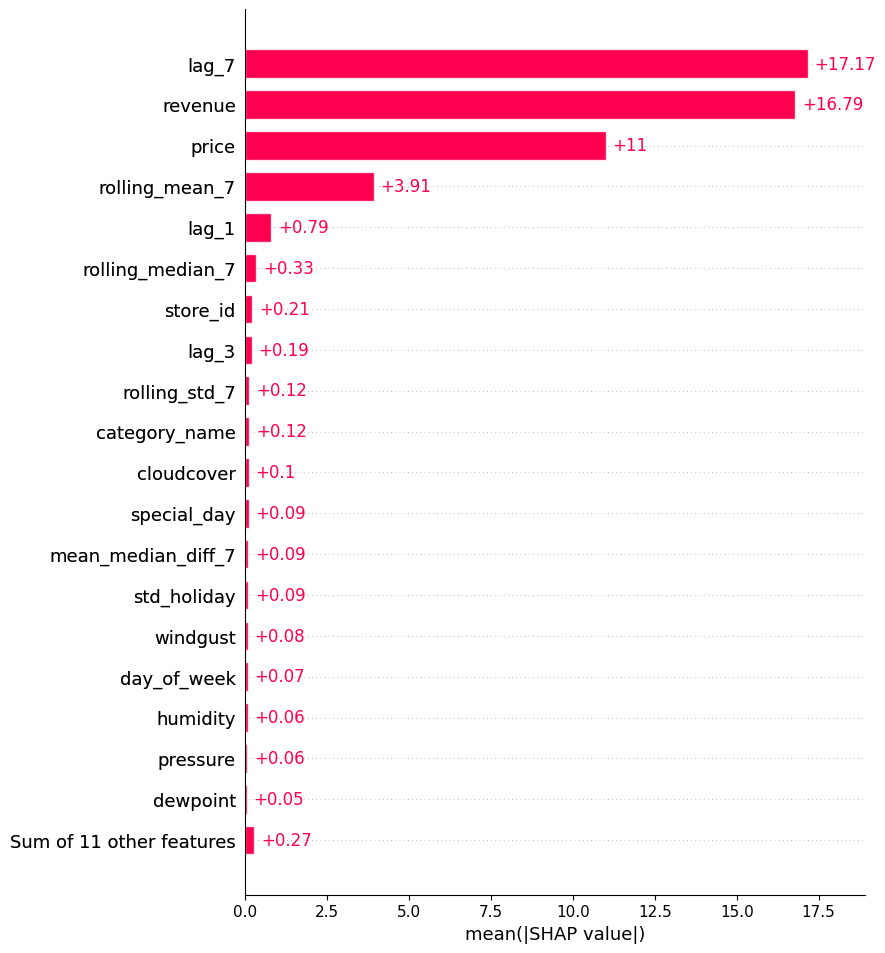

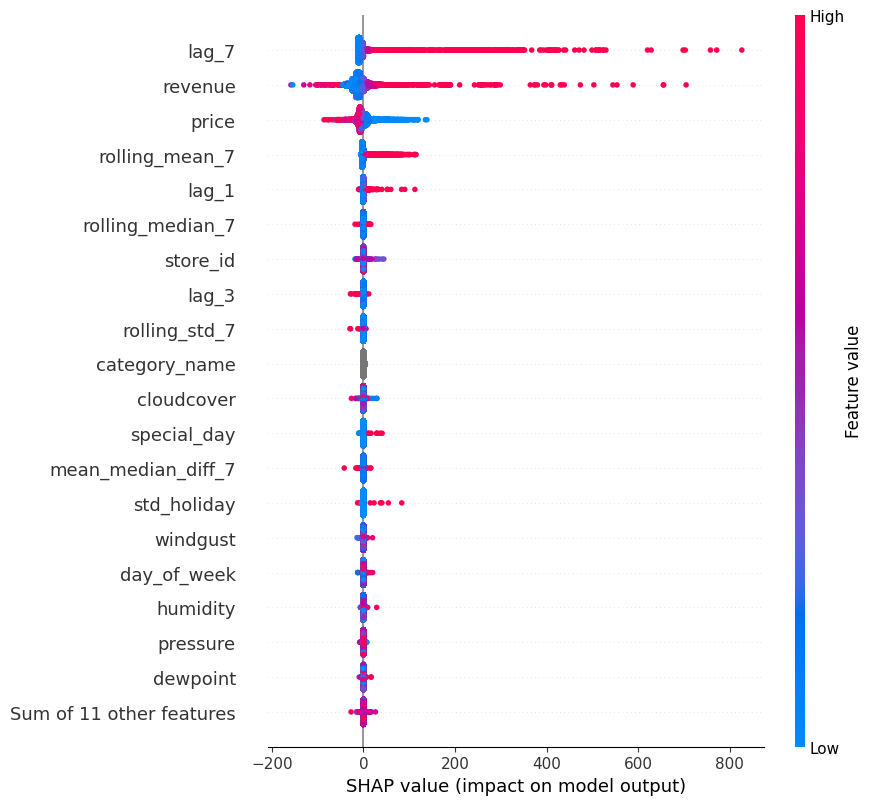

--------------------------------------------------------------------------------


In [43]:
print('performance WITHOUT revenue and UNSCALED, no OHE:\n')
compare_models(models, X_train, y_train, X_test, y_test)

In [45]:
# model only (no function)

reg = lightgbm.LGBMRegressor(n_estimators=1000, subsample_for_bin=100000, subsample_freq=1, random_state=42, metric='rmse')

reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4310
[LightGBM] [Info] Number of data points in the train set: 113453, number of used features: 30
[LightGBM] [Info] Start training from score 33.690420
MAE: 1.463867608442655
RMSE: 12.176833417492984



## __GridSearchCV__

In [160]:
# params to test
# params = {
#     "n_estimators": [100, 300, 500],
#     "learning_rate": [0.03, 0.05],
#     "num_leaves": [31, 63],
#     "min_child_samples": [20, 50],
#     "subsample": [0.8],
#     "colsample_bytree": [0.8],
#     "reg_alpha": [0, 1],
#     "reg_lambda": [0, 1]
# }# 
# 
# 

# # folds for correct splits
# tscv = TimeSeriesSplit(n_splits=3, gap=7)# 

# # cv
# grid_lgbm = GridSearchCV(
#     estimator=reg,
#     param_grid=params,
#     scoring='neg_median_absolute_error',
#     cv=tscv,
#     verbose=0
# )# 

# grid_lgbm.fit(X_train, y_train)

In [161]:
# best_params_:

# {'colsample_bytree': 0.8,
#  'learning_rate': 0.03,
#  'min_child_samples': 20,
#  'n_estimators': 2000,
#  'num_leaves': 63,
#  'reg_alpha': 1,
#  'reg_lambda': 1,
#  'subsample': 0.8}


In [162]:
# grid_lgbm.best_params_

In [47]:
from joblib import load

grid_lgbm = load('gridsearchCV.joblib')


In [48]:
# best model so far
y_pred_grid = grid_lgbm.best_estimator_.predict(X_test)

print('LightGBM, GridSearch, best_estimator:')
print('MAE:', mean_absolute_error(y_test, y_pred_grid))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_grid)))
print()



LightGBMError: The number of features in data (30) is not the same as it was in training data (29).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

## __best_model by category__

In [ ]:
X_test.head()

In [46]:
compare_dict = {
    #'week': X_test['week'],
    'dates': test_dates,
    'category_name': X_test['category_name'],
    'sold_quantity_true': y_test,
    'sold_quantity_pred': y_pred_grid 
}


test_compare = pd.DataFrame(compare_dict)

cats = test_compare.category_name.unique()
cats_count = test_compare.category_name.nunique()

selection = test_compare.query('category_name == "Kaltgetränke 19%"')

plt.figure(figsize=(15,6))

plt.scatter(test_compare.dates, test_compare.sold_quantity_true, )
#plt.plot(test_compare.week, test_compare.sold_quantity_pred, alpha=0.5)

plt.show()

NameError: name 'y_pred_grid' is not defined

## __RandomizedSearchCV__

In [2]:
# params

# params_rand = {
#     "learning_rate": uniform(0.02, 0.05),   # 0.02–0.07
#     "num_leaves": randint(31, 128),
#     "min_child_samples": randint(20, 100),
#     "subsample": uniform(0.6, 0.4),         # 0.6–1.0
#     "colsample_bytree": uniform(0.6, 0.4),
#     "reg_alpha": uniform(0, 2),
#     "reg_lambda": uniform(0, 2)
# }# 
# 

# rand_lgbm = RandomizedSearchCV(
#     estimator=reg, 
#     param_distributions=params_rand,
#     cv=tscv,
#     n_iter=40,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42,
#     scoring="neg_median_absolute_error",
# )# 

# # eval set# 

# split_idx = int(len(X_train) * 0.8)# 

# X_tr = X_train[:split_idx]
# X_val = X_train[split_idx:]# 

# y_tr = y_train[:split_idx]
# y_val = y_train[split_idx:]# 





In [135]:
# fit
# rand_lgbm.fit(X_tr, y_tr, 
#             eval_set=[(X_val, y_val)],
#             eval_metric="l1",
#             callbacks=[lightgbm.early_stopping(50, verbose=False)])

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4160
[LightGBM] [Info] Number of data points in the train set: 90762, number of used features: 29
[LightGBM] [Info] Start training from score 33.984279


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor...sample_freq=1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....001275043D6D0>, 'learning_rate': <scipy.stats....001273C0B8EC0>, 'min_child_samples': <scipy.stats....001275043D310>, 'num_leaves': <scipy.stats....001273C2806E0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_median_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across call

In [3]:
# y_pred_rand = rand_lgbm.best_estimator_.predict(X_test)# 

# print('LightGBM, RandomSearch, best_estimator:')
# print('MAE:', mean_absolute_error(y_test, y_pred_rand))
# print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rand)))
# print()

## export model

In [63]:
from joblib import dump

# export whole gridsearchCV
# dump(grid_lgbm, 'gridsearchCV.joblib')

### XGBoost

In [ ]:
# xgboost 
xgb = xgboost.XGBRegressor(tree_method='hist', enable_categorical=False)
xgb.fit(X_train_scaled, y_train)




In [ ]:
y_pred_xgb = xgb.predict(X_test_scaled)
print('XGBoost:')
print('MAE:', mean_absolute_error(y_test, y_pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

### LightGBM

In [ ]:
# lightgbm
lgb = lightgbm.LGBMRegressor(n_estimators=1000, subsample_for_bin=100000, random_state=42, metric='rmse')
lgb.fit(X_train_scaled, y_train)

In [ ]:
y_pred_lgb = lgb.predict(X_test_scaled)
print('LighGBM Test:')
print('MAE:', mean_absolute_error(y_test, y_pred_lgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lgb)))

print()

y_pred_lgb_train = lgb.predict(X_train_scaled)
print('LighGBM Train:')
print('MAE:', mean_absolute_error(y_train, y_pred_lgb_train))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_pred_lgb_train)))



In [ ]:
# LightGBM:
# MAE: 0.20288126272325116
# RMSE: 3.2958418891273156

# LighGBM:
# MAE: 0.1459244602906927
# RMSE: 3.3463232821532256

### Gradient Boost

In [ ]:
# gradient boost
from sklearn.ensemble import GradientBoostingRegressor



In [ ]:
gb = GradientBoostingRegressor()
gb.fit(X_train_scaled, y_train)


In [ ]:
y_pred_gb = gb.predict(X_test_scaled)
print('Gradient Boost Test:')
print('MAE:', mean_absolute_error(y_test, y_pred_gb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_gb)))

print()

y_pred_gb_train = gb.predict(X_train_scaled)
print('Gradient Boost Train:')
print('MAE:', mean_absolute_error(y_train, y_pred_gb_train))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_pred_gb_train)))

### RandomForest

In [ ]:
# RandomForest
rf = RandomForestRegressor()
rf.fit(X_train_scaled, y_train)

In [ ]:
y_pred_rf = rf.predict(X_test_scaled)
print('RandomForest Test:')
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))